In [3]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = 5264

import numpy as np

# Choices: use default_rng with a fixed seed for reproducibility; sort timestamps so data
# can be plotted as a time series; use floats for means/stds to be explicit.
rng = np.random.default_rng(5264)
n = 200
# generate timestamps and sort them to simulate measurements over time
timestamps = np.sort(rng.uniform(0, 10, n))
# generate independent sensor readings at those timestamps
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n)

# quick summary to confirm statistics roughly match the specified means/stds
print('timestamps (first 5):', timestamps[:5])
print('sensor_a mean/std: {:.2f}/{:.2f}'.format(np.mean(sensor_a), np.std(sensor_a)))
print('sensor_b mean/std: {:.2f}/{:.2f}'.format(np.mean(sensor_b), np.std(sensor_b)))
print('sensor_a shape:', sensor_a.shape)


timestamps (first 5): [0.05451982 0.10602171 0.24084611 0.24643161 0.33829822]
sensor_a mean/std: 24.84/2.84
sensor_b mean/std: 26.83/4.69
sensor_a shape: (200,)


In [ ]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.

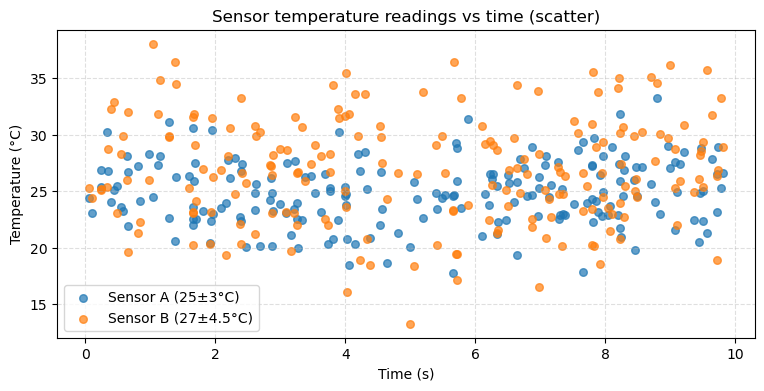

In [4]:
import matplotlib.pyplot as plt

# Implementing intent: scatter plot of sensor readings vs time for both sensors.
plt.figure(figsize=(9,4))
plt.scatter(timestamps, sensor_a, color='tab:blue', s=30, alpha=0.7, label='Sensor A (25±3°C)')
plt.scatter(timestamps, sensor_b, color='tab:orange', s=30, alpha=0.7, label='Sensor B (27±4.5°C)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Sensor temperature readings vs time (scatter)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


In [ ]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

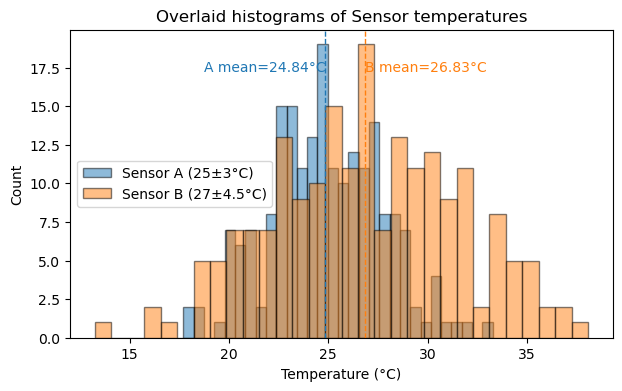

In [5]:
import matplotlib.pyplot as plt

# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.
bins = 30
plt.figure(figsize=(7,4))
plt.hist(sensor_a, bins=bins, alpha=0.5, label='Sensor A (25±3°C)', color='tab:blue', edgecolor='black')
plt.hist(sensor_b, bins=bins, alpha=0.5, label='Sensor B (27±4.5°C)', color='tab:orange', edgecolor='black')
ma = sensor_a.mean()
mb = sensor_b.mean()
plt.axvline(ma, color='tab:blue', linestyle='--', linewidth=1)
plt.axvline(mb, color='tab:orange', linestyle='--', linewidth=1)
plt.text(ma, plt.ylim()[1]*0.9, f'A mean={ma:.2f}°C', color='tab:blue', ha='right', va='top')
plt.text(mb, plt.ylim()[1]*0.9, f'B mean={mb:.2f}°C', color='tab:orange', ha='left', va='top')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Overlaid histograms of Sensor temperatures')
plt.legend()
plt.grid(False)
plt.show()


In [ ]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

/var/folders/n1/ywlnd9lx4v795pjdcz7c0yn40000gn/T/ipykernel_41625/2069227233.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, notch=True, patch_artist=True, labels=labels, widths=0.6, showfliers=True)


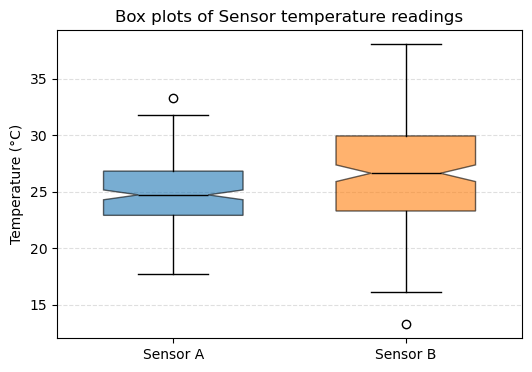

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Box plot comparing Sensor A and Sensor B distributions.
# Notched boxes show median confidence; patch_artist=True for colored boxes.
data = [sensor_a, sensor_b]
labels = ['Sensor A', 'Sensor B']
fig, ax = plt.subplots(figsize=(6,4))
bp = ax.boxplot(data, notch=True, patch_artist=True, labels=labels, widths=0.6, showfliers=True)
# color the boxes to match scatter/hist color scheme
colors = ['tab:blue', 'tab:orange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
# customize medians and whiskers
for median in bp['medians']:
    median.set(color='black', linewidth=1)
ax.set_ylabel('Temperature (°C)')
ax.set_title('Box plots of Sensor temperature readings')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()
